In [1]:
from alerce.core import Alerce
from astropy.table import vstack, Table
import json
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
import george
import scipy.optimize as op
import emcee

In [2]:
#open light curves
with open("../Data/Ia.json", 'r') as f:
    light_curves = json.load(f)

In [3]:
import utils

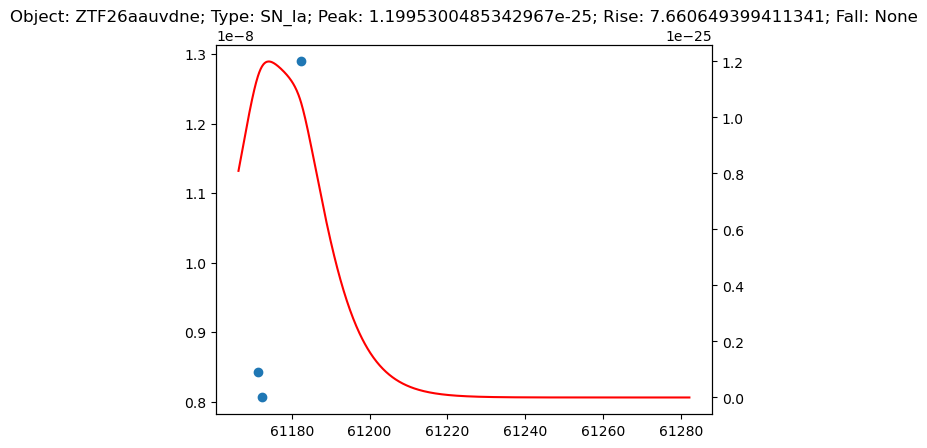

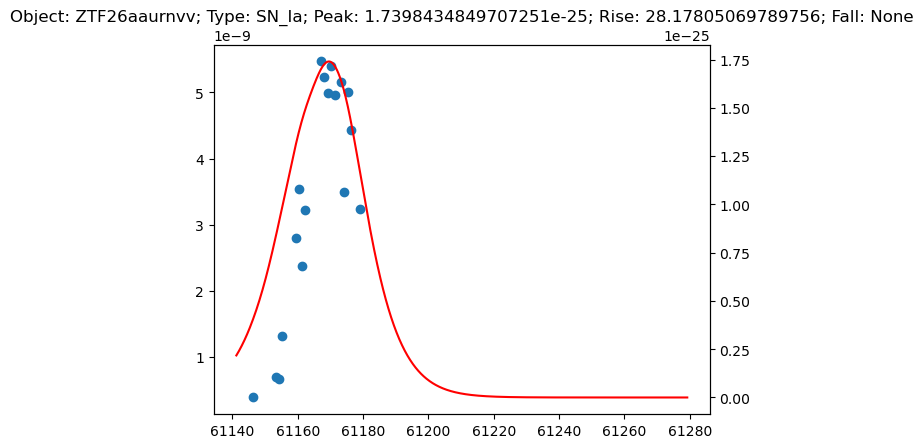

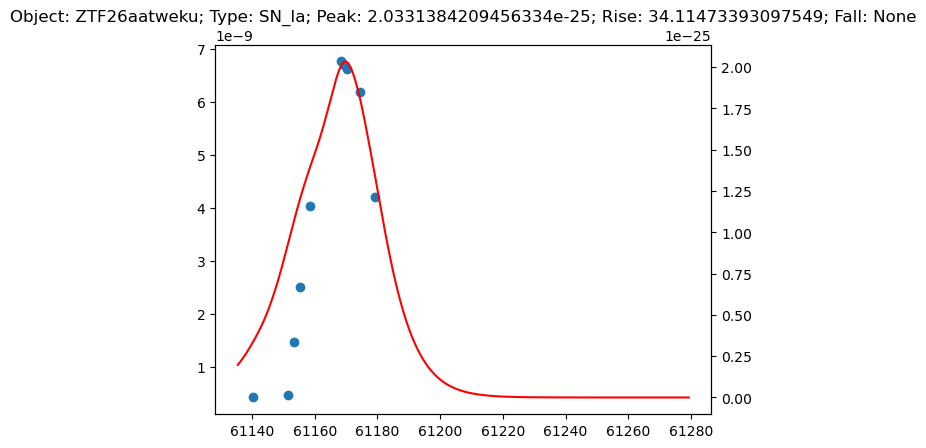

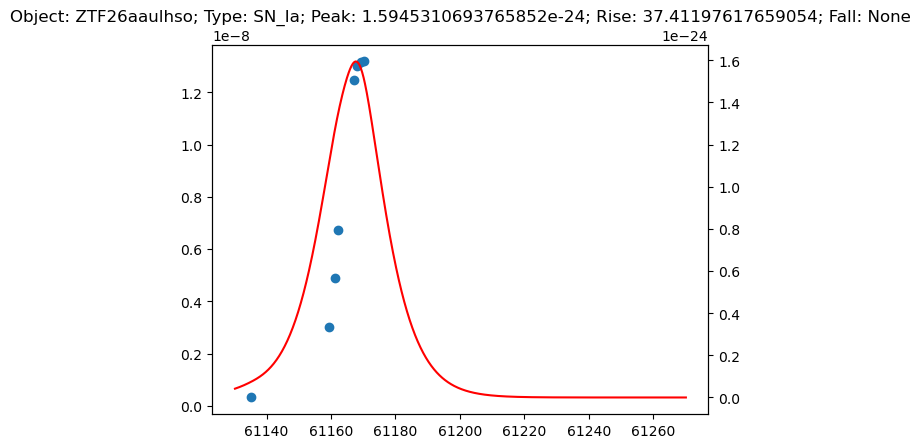

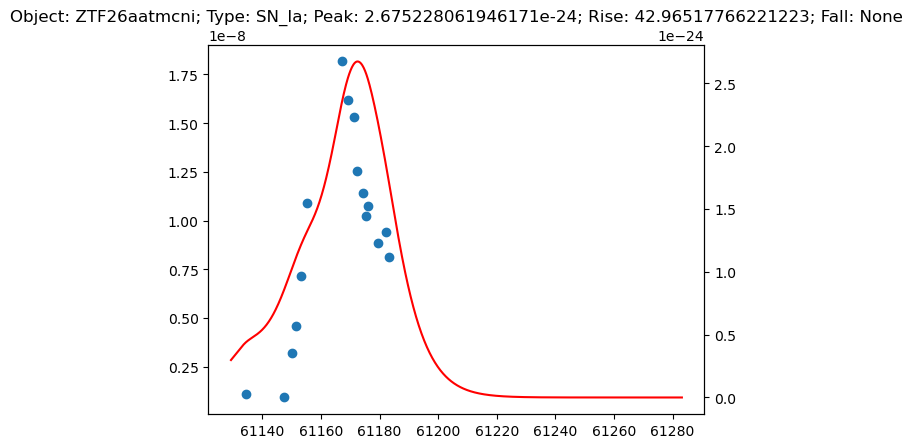

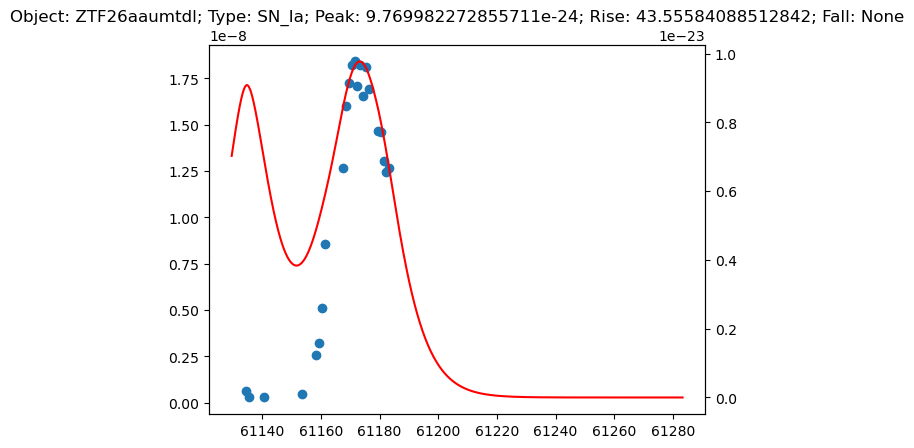

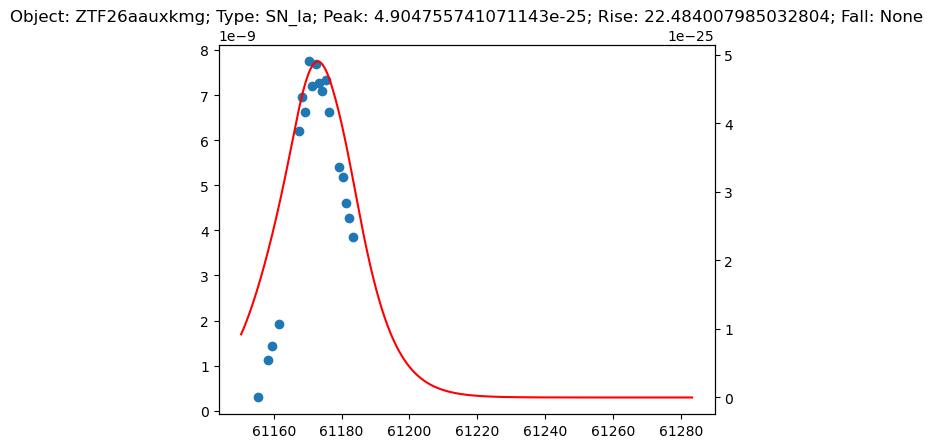

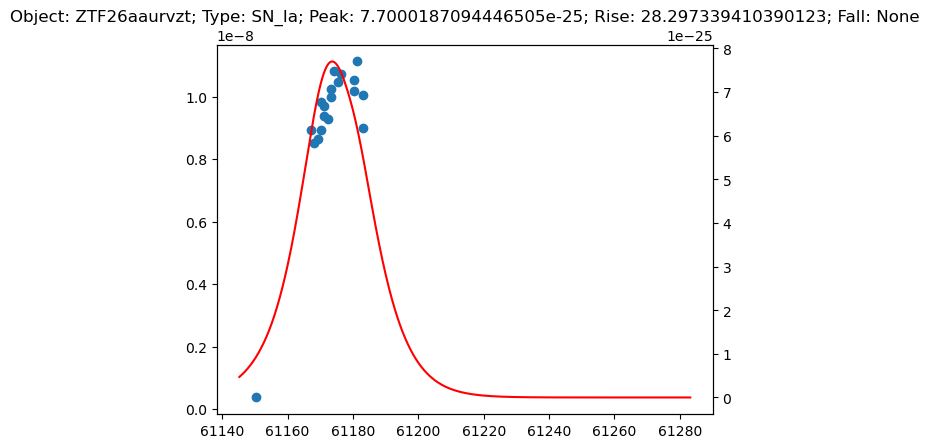

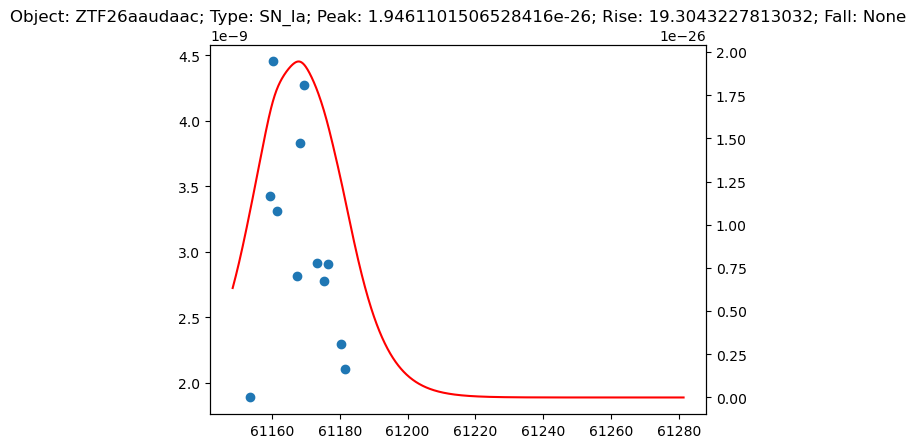

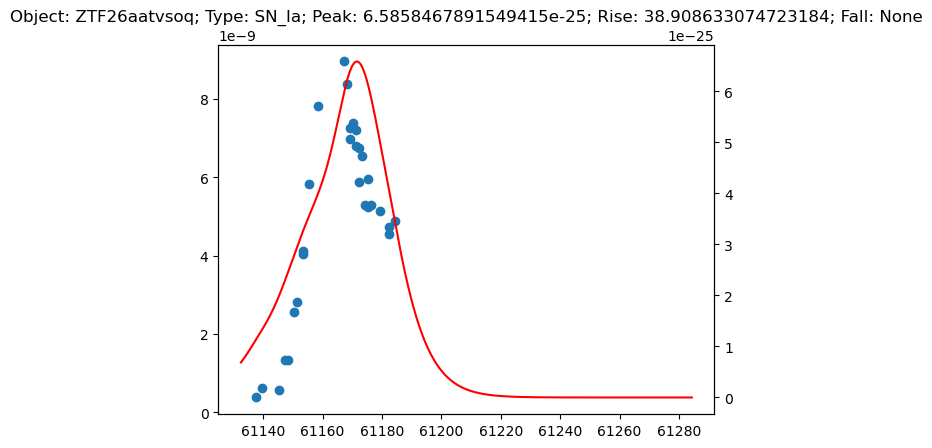

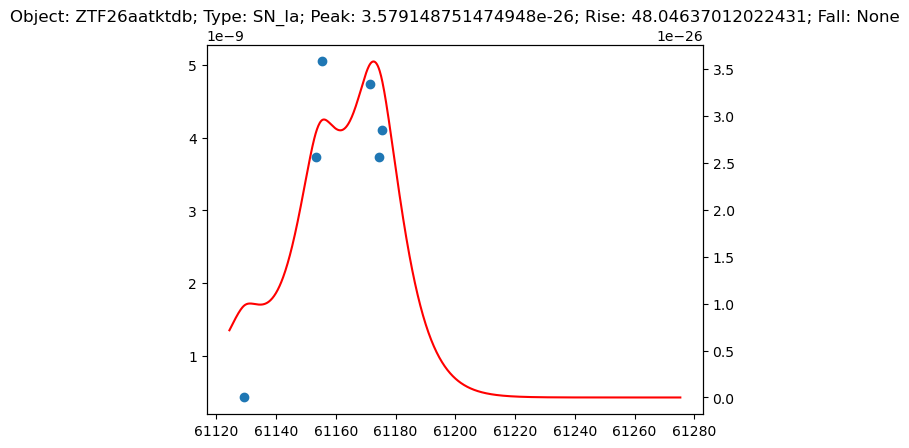

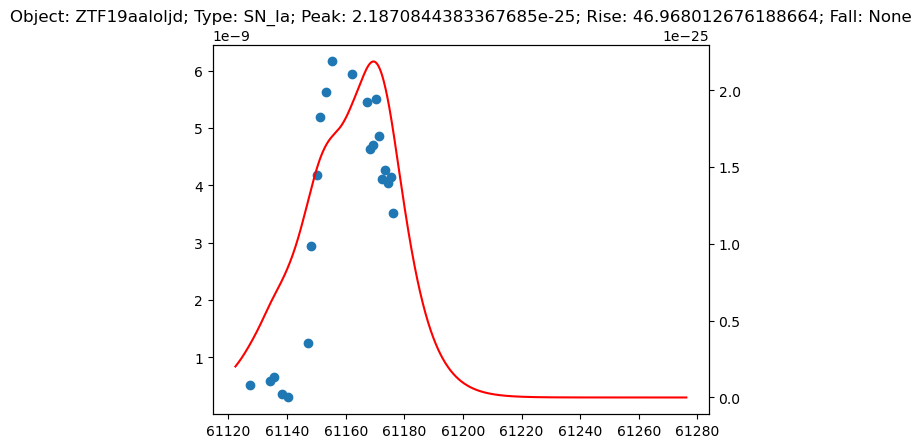

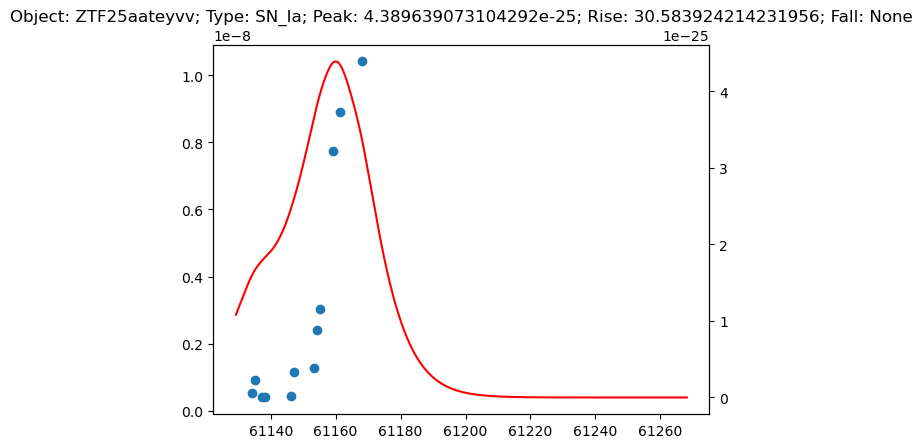

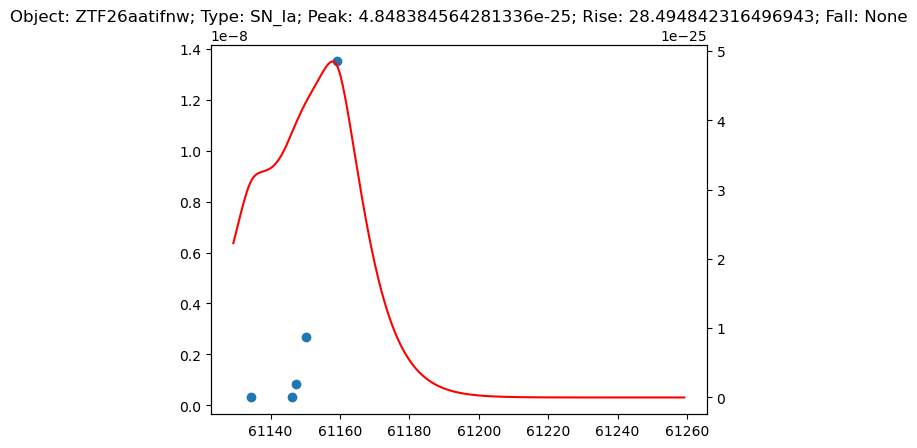

In [4]:
dic_curves = []
for light in light_curves:

    if len(light) > 10:

        #fetch time, psuedo flux, and psuedo flux error
        time, mag_flipped, error = utils.decompose_curve(light)

        if len(mag_flipped) > 0:

            #initialize plotting figure
            fig, ax1 = plt.subplots()
            
            #plot raw lightcurve
            ax1.scatter(time, mag_flipped, marker='o')
            
            #fit line to curve
            pred, pred_var, x_fit = utils.fit_george(time, mag_flipped, error)

            #find peak
            peak = np.max(pred)

            #find rise time
            rise_time = utils.get_rise_time(pred, x_fit, peak)

            #find fall time
            fall_time = utils.get_fall_time(pred, x_fit, peak)

            #add curve to dictionary and append to list
            error = np.pow(pred_var, 0.5)
            dic = {"object": light[0]["oid"], "type": "SNIa", "mjd": x_fit, "mag": pred, "error": error, "peak": peak, "rise": rise_time, "fall": fall_time}
            dic_curves.append(dic)

            #split axis
            ax2 = ax1.twinx()

            #plot george
            ax2.plot(x_fit, pred, color='r')
        
            #ax1.fill_between(x_fit, pred - error, pred + error, interpolate=True)
            plt.title(f"Object: {light[0]["oid"]}; Type: SN_Ia; Peak: {peak}; Rise: {rise_time}; Fall: {fall_time}")

            plt.show()
            plt.close()

table_curves = vstack(dic_curves)
#table_curves.write('SNIa_test.ecsv', format='ascii.ecsv', overwrite=True)